In [ ]:
# Cell 1 — imports and small utilities
import os, time
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import svd, eigh, LinAlgError
from scipy.sparse.linalg import LinearOperator, eigsh

np.set_printoptions(precision=6, suppress=True)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

FIGDIR = "figureAKLT"
os.makedirs(FIGDIR, exist_ok=True)

def savefig(name):
    path = os.path.join(FIGDIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print("saved:", path)

def robust_svd(M):
    try:
        U, s, Vh = svd(M, full_matrices=False)
    except LinAlgError:
        U, s, Vh = svd(M, full_matrices=False, lapack_driver='gesvd')
    idx = np.argsort(s)[::-1]
    return U[:, idx], s[idx], Vh[idx, :]

def truncate_svd(U, s, Vh, Dmax, eps=1e-12, eps_abs=1e-14):
    if s[0] < eps_abs:
        D = 1
    else:
        D = np.sum(s > max(eps * s[0], eps_abs))
        D = max(1, min(Dmax, D))
    discarded = np.sum(s[D:]**2).real
    return U[:, :D], s[:D], Vh[:D, :], discarded

In [ ]:
# Cell 2 — local operators
def spin_half_ops(dtype=np.complex128):
    I = np.eye(2, dtype=dtype)
    Sp = np.array([[0, 1], [0, 0]], dtype=dtype)
    Sm = np.array([[0, 0], [1, 0]], dtype=dtype)
    Sz = np.array([[0.5, 0], [0, -0.5]], dtype=dtype)
    Sx = 0.5 * (Sp + Sm)
    Sy = -0.5j * (Sp - Sm)
    return {"I": I, "Sp": Sp, "Sm": Sm, "Sz": Sz, "Sx": Sx, "Sy": Sy}

def spin_one_ops(dtype=np.complex128):
    I = np.eye(3, dtype=dtype)
    Sx = (1/np.sqrt(2)) * np.array([[0, 1, 0],
                                    [1, 0, 1],
                                    [0, 1, 0]], dtype=dtype)
    Sy = (1j/np.sqrt(2)) * np.array([[0, -1, 0],
                                     [1,  0, -1],
                                     [0,  1, 0]], dtype=dtype)
    Sz = np.array([[1, 0, 0],
                   [0, 0, 0],
                   [0, 0, -1]], dtype=dtype)
    return {"I": I, "Sx": Sx, "Sy": Sy, "Sz": Sz}

In [ ]:
# Cell 3 — MPO class
class MPO:
    def __init__(self, Wlist, b_left, b_right, model_name="unknown"):
        self.W = Wlist
        self.L = len(Wlist)
        self.b_left = b_left
        self.b_right = b_right
        self.model_name = model_name
        self.d = Wlist[0].shape[2]

    @staticmethod
    def heisenberg(L, J=1.0, Jz=1.0, h=0.0, dtype=np.complex128):
        ops = spin_half_ops(dtype=dtype)
        I, Sp, Sm, Sz = ops["I"], ops["Sp"], ops["Sm"], ops["Sz"]

        Dw, d = 5, 2
        Wbulk = np.zeros((Dw, Dw, d, d), dtype=dtype)
        Wbulk[0, 0] = I
        Wbulk[1, 0] = Sp
        Wbulk[2, 0] = Sm
        Wbulk[3, 0] = Sz
        Wbulk[4, 0] = -h * Sz
        Wbulk[4, 1] = (J/2) * Sm
        Wbulk[4, 2] = (J/2) * Sp
        Wbulk[4, 3] = Jz * Sz
        Wbulk[4, 4] = I

        Wleft = np.zeros((1, Dw, d, d), dtype=dtype)
        Wright = np.zeros((Dw, 1, d, d), dtype=dtype)
        Wleft[0] = Wbulk[4]
        Wright[:, 0] = Wbulk[:, 0]

        Wlist = [Wleft] + [Wbulk.copy() for _ in range(1, L-1)] + [Wright]
        return MPO(Wlist, 4, 0, model_name="Heisenberg")

    @staticmethod
    def aklt(L, dtype=np.complex128):
        ops = spin_one_ops(dtype=dtype)
        I, Sx, Sy, Sz = ops["I"], ops["Sx"], ops["Sy"], ops["Sz"]

        Svec = [Sx, Sy, Sz]
        Qvec = [Sa @ Sb for Sa in Svec for Sb in Svec]

        Dw, d = 14, 3
        Wbulk = np.zeros((Dw, Dw, d, d), dtype=dtype)

        Wbulk[0, 0] = I
        for a in range(3):
            Wbulk[1+a, 0] = Svec[a]
        for q in range(9):
            Wbulk[4+q, 0] = Qvec[q]
        for a in range(3):
            Wbulk[13, 1+a] = Svec[a]
        for q in range(9):
            Wbulk[13, 4+q] = (1/3.0) * Qvec[q]
        Wbulk[13, 13] = I

        Wleft = np.zeros((1, Dw, d, d), dtype=dtype)
        Wright = np.zeros((Dw, 1, d, d), dtype=dtype)
        Wleft[0] = Wbulk[13]
        Wright[:, 0] = Wbulk[:, 0]

        Wlist = [Wleft] + [Wbulk.copy() for _ in range(1, L-1)] + [Wright]
        return MPO(Wlist, 13, 0, model_name="AKLT")

    def expectation(self, mps):
        env = np.array([[[1.0+0j]]], dtype=np.complex128)
        for A, W in zip(mps.tensors, self.W):
            env = np.einsum("bxy,xsX,bBst,ytY->BXY", env, A.conj(), W, A, optimize=True)
        return env[0, 0, 0]

In [ ]:
# Cell 4 — MPS class
class MPS:
    def __init__(self, tensors):
        self.tensors = [A.astype(np.complex128).copy() for A in tensors]
        self.L = len(tensors)
        self.d = tensors[0].shape[1]

    @staticmethod
    def random(L, d, Dmax, seed=1234, dtype=np.complex128):
        rng = np.random.default_rng(seed)
        dims = [1]
        for _ in range(1, L):
            dims.append(min(Dmax, dims[-1] * d))
        dims.append(1)
        for i in range(L-1, 0, -1):
            dims[i] = min(dims[i], dims[i+1] * d)

        tensors = []
        for i in range(L):
            Dl, Dr = dims[i], dims[i+1]
            A = rng.normal(size=(Dl, d, Dr)) + 1j * rng.normal(size=(Dl, d, Dr))
            A = A.astype(dtype)
            A /= np.linalg.norm(A)
            tensors.append(A)
        return MPS(tensors)

    @staticmethod
    def aklt_exact(L, dtype=np.complex128):
        Aplus = np.array([[0, np.sqrt(2/3)],
                          [0, 0]], dtype=dtype)
        A0 = np.array([[-1/np.sqrt(3), 0],
                       [0,  1/np.sqrt(3)]], dtype=dtype)
        Aminus = np.array([[0, 0],
                           [-np.sqrt(2/3), 0]], dtype=dtype)

        Abulk = np.stack([Aplus, A0, Aminus], axis=1)  # (2,3,2)
        vL = np.array([[1.0, 0.0]], dtype=dtype)
        vR = np.array([[1.0], [0.0]], dtype=dtype)

        tensors = []
        for i in range(L):
            if i == 0:
                T = np.tensordot(vL, Abulk, axes=([1], [0]))
            elif i == L - 1:
                T = np.tensordot(Abulk, vR, axes=([2], [0]))
            else:
                T = Abulk.copy()
            tensors.append(T.astype(dtype))
        return MPS(tensors)

    def copy(self):
        return MPS([A.copy() for A in self.tensors])

    def overlap(self, other):
        env = np.array([[1.0+0j]], dtype=np.complex128)
        for A, B in zip(self.tensors, other.tensors):
            env = np.einsum("xy,xsX,ysY->XY", env, A.conj(), B, optimize=True)
        return env[0, 0]

    def normalize(self):
        nrm = np.sqrt(np.abs(self.overlap(self)))
        self.tensors[0] /= nrm
        return self

    def right_canonicalize(self, Dmax=None, eps=1e-12):
        out = [A.copy() for A in self.tensors]
        G = np.array([[1.0+0j]], dtype=np.complex128)
        for i in range(len(out)-1, 0, -1):
            A = np.tensordot(out[i], G, axes=([2], [0]))
            Dl, d, Dr = A.shape
            M = A.reshape(Dl, d*Dr, order='C')
            U, s, Vh = robust_svd(M)
            if Dmax is not None:
                U, s, Vh, _ = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
            out[i] = Vh.reshape(len(s), d, Dr, order='C')
            G = U @ np.diag(s)
        out[0] = np.tensordot(out[0], G, axes=([2], [0]))
        self.tensors = out
        return self

    def left_canonicalize(self):
        out = [A.copy() for A in self.tensors]
        C = np.array([[1.0+0j]], dtype=np.complex128)
        for i in range(len(out)-1):
            A = np.tensordot(C, out[i], axes=([1], [0]))
            Dl, d, Dr = A.shape
            M = A.reshape(Dl*d, Dr, order='C')
            Q, R = np.linalg.qr(M, mode='reduced')
            out[i] = Q.reshape(Dl, d, Q.shape[1], order='C')
            C = R
        out[-1] = np.tensordot(C, out[-1], axes=([1], [0]))
        self.tensors = out
        return self

    def to_statevector(self):
        psi = self.tensors[0][0, :, :]
        for i in range(1, len(self.tensors)):
            psi = np.tensordot(psi, self.tensors[i], axes=([-1], [0]))
        psi = psi[..., 0]
        return np.asarray(psi, dtype=np.complex128).reshape(-1, order='C')

    def bond_dims(self):
        return [A.shape[2] for A in self.tensors[:-1]]

In [ ]:
# Cell 5 — DMRGEngine class
class DMRGEngine:
    def __init__(self, mpo):
        self.mpo = mpo

    def update_left_env(self, Lold, A, W):
        return np.einsum("bxy,ytY,bBst,xsX->BXY", Lold, A, W, A.conj(), optimize=True)

    def update_right_env(self, Rold, A, W):
        return np.einsum("BXY,ytY,bBst,xsX->bxy", Rold, A, W, A.conj(), optimize=True)

    def build_left_envs(self, mps):
        Wlist = self.mpo.W
        L_env = [None] * mps.L
        L_env[0] = np.zeros((Wlist[0].shape[1], 1, 1), dtype=np.complex128)
        L_env[0][self.mpo.b_left, 0, 0] = 1.0
        for i in range(mps.L - 1):
            L_env[i+1] = self.update_left_env(L_env[i], mps.tensors[i], Wlist[i])
        return L_env

    def build_right_envs(self, mps):
        Wlist = self.mpo.W
        R_env = [None] * mps.L
        R_env[-1] = np.zeros((Wlist[-1].shape[0], 1, 1), dtype=np.complex128)
        R_env[-1][self.mpo.b_right, 0, 0] = 1.0
        for i in range(mps.L - 1, 0, -1):
            R_env[i-1] = self.update_right_env(R_env[i], mps.tensors[i], Wlist[i])
        return R_env

    def apply_local(self, v, Lenv, W, Renv, shape):
        Dl, d, Dr = shape
        V = v.reshape((Dl, d, Dr), order='C')
        T1 = np.einsum("bxy,ytY->bxtY", Lenv, V, optimize=True)
        T2 = np.einsum("bxtY,bBst->BxsY", T1, W, optimize=True)
        Vnew = np.einsum("BxsY,BXY->xsX", T2, Renv, optimize=True)
        return Vnew.reshape(-1, order='C')

    def dense_local_hamiltonian(self, Lenv, W, Renv, shape):
        dim = np.prod(shape)
        H = np.zeros((dim, dim), dtype=np.complex128)
        for j in range(dim):
            e = np.zeros(dim, dtype=np.complex128)
            e[j] = 1.0
            H[:, j] = self.apply_local(e, Lenv, W, Renv, shape)
        return 0.5 * (H + H.conj().T)

    def solve_local(self, Lenv, W, Renv, Minit, tol=1e-10, maxiter=300, dense_cutoff=64):
        shape = Minit.shape
        dim = np.prod(shape)
        if dim <= dense_cutoff:
            H = self.dense_local_hamiltonian(Lenv, W, Renv, shape)
            vals, vecs = eigh(H)
            return vals[0].real, vecs[:, 0].reshape(shape, order='C')

        def matvec(x):
            return self.apply_local(x, Lenv, W, Renv, shape)

        Heff = LinearOperator((dim, dim), matvec=matvec, rmatvec=matvec, dtype=np.complex128)
        v0 = Minit.reshape(-1, order='C').copy()
        try:
            vals, vecs = eigsh(Heff, k=1, which='SA', v0=v0, tol=tol, maxiter=maxiter)
            return vals[0].real, vecs[:, 0].reshape(shape, order='C')
        except Exception:
            H = self.dense_local_hamiltonian(Lenv, W, Renv, shape)
            vals, vecs = eigh(H)
            return vals[0].real, vecs[:, 0].reshape(shape, order='C')

    def move_center_right(self, M, Mnext, Dmax, eps=1e-12):
        Dl, d, Dr = M.shape
        Mmat = M.reshape(Dl*d, Dr, order='C')
        U, s, Vh = robust_svd(Mmat)
        U, s, Vh, discarded = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
        Aleft = U.reshape(Dl, d, len(s), order='C')
        gauge = np.diag(s) @ Vh
        new_next = np.tensordot(gauge, Mnext, axes=([1], [0]))
        return Aleft, new_next, discarded, s

    def move_center_left(self, Mprev, M, Dmax, eps=1e-12):
        Dl, d, Dr = M.shape
        Mmat = M.reshape(Dl, d*Dr, order='C')
        U, s, Vh = robust_svd(Mmat)
        U, s, Vh, discarded = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
        Bright = Vh.reshape(len(s), d, Dr, order='C')
        gauge = U @ np.diag(s)
        new_prev = np.tensordot(Mprev, gauge, axes=([2], [0]))
        return new_prev, Bright, discarded, s

    def single_site(self, mps, Dmax, nsweeps=10, eig_tol=1e-10, svd_eps=1e-12,
                    energy_tol=1e-9, min_sweeps=2, verbose=True):
        mps = mps.copy().right_canonicalize(Dmax=Dmax, eps=svd_eps).normalize()
        energies, trunc_hist, entropy_hist = [], [], []

        for sweep in range(nsweeps):
            R_env = self.build_right_envs(mps)
            Lenv = np.zeros((self.mpo.W[0].shape[1], 1, 1), dtype=np.complex128)
            Lenv[self.mpo.b_left, 0, 0] = 1.0

            last_E = None
            sweep_disc, sweep_S = [], []

            for i in range(mps.L - 1):
                E, Mopt = self.solve_local(Lenv, self.mpo.W[i], R_env[i], mps.tensors[i], tol=eig_tol)
                last_E = E
                Aleft, new_next, disc, s = self.move_center_right(Mopt, mps.tensors[i+1], Dmax=Dmax, eps=svd_eps)
                mps.tensors[i], mps.tensors[i+1] = Aleft, new_next
                Lenv = self.update_left_env(Lenv, mps.tensors[i], self.mpo.W[i])
                sweep_disc.append(disc)
                p = np.abs(s)**2
                p = p / np.sum(p)
                p = p[p > 1e-15]
                sweep_S.append(float(-(p * np.log(p)).sum().real))

            E, Mopt = self.solve_local(Lenv, self.mpo.W[-1], R_env[-1], mps.tensors[-1], tol=eig_tol)
            mps.tensors[-1] = Mopt
            last_E = E

            L_env = self.build_left_envs(mps)
            Renv = np.zeros((self.mpo.W[-1].shape[0], 1, 1), dtype=np.complex128)
            Renv[self.mpo.b_right, 0, 0] = 1.0

            for i in range(mps.L - 1, 0, -1):
                E, Mopt = self.solve_local(L_env[i], self.mpo.W[i], Renv, mps.tensors[i], tol=eig_tol)
                last_E = E
                new_prev, Bright, disc, s = self.move_center_left(mps.tensors[i-1], Mopt, Dmax=Dmax, eps=svd_eps)
                mps.tensors[i-1], mps.tensors[i] = new_prev, Bright
                Renv = self.update_right_env(Renv, mps.tensors[i], self.mpo.W[i])
                sweep_disc.append(disc)
                p = np.abs(s)**2
                p = p / np.sum(p)
                p = p[p > 1e-15]
                sweep_S.append(float(-(p * np.log(p)).sum().real))

            E, Mopt = self.solve_local(L_env[0], self.mpo.W[0], Renv, mps.tensors[0], tol=eig_tol)
            mps.tensors[0] = Mopt

            mps.normalize()
            energies.append(float(last_E))
            trunc_hist.append(float(np.sum(sweep_disc).real))
            entropy_hist.append(float(max(sweep_S) if len(sweep_S) else 0.0))

            dE = abs(energies[-1] - energies[-2]) if len(energies) >= 2 else np.nan
            if verbose:
                print(f"sweep {sweep+1:2d}: E = {energies[-1]: .12f}, dE = {dE:.3e}, trunc_sum = {trunc_hist[-1]:.3e}, Smax = {entropy_hist[-1]:.6f}")

            if (sweep+1) >= min_sweeps and len(energies) >= 2 and abs(energies[-1] - energies[-2]) < energy_tol:
                if verbose:
                    print(f"Converged early: |dE| < {energy_tol}")
                break

        return mps, np.array(energies), np.array(trunc_hist), np.array(entropy_hist)

In [ ]:
# Cell 6 — extend DMRGEngine with two-site
def _merge_two_sites(A, B):
    return np.tensordot(A, B, axes=([2], [0]))

def _apply_two_site(v, Lenv, W1, W2, Renv, shape):
    Dl, d1, d2, Dr = shape
    Theta = v.reshape((Dl, d1, d2, Dr), order='C')
    T1 = np.einsum("bxy,ytuY->bxtuY", Lenv, Theta, optimize=True)
    T2 = np.einsum("bxtuY,bcst->cxsuY", T1, W1, optimize=True)
    T3 = np.einsum("cxsuY,cBvu->BxsvY", T2, W2, optimize=True)
    out = np.einsum("BxsvY,BXY->xsvX", T3, Renv, optimize=True)
    return out.reshape(-1, order='C')

def _dense_two_site(Lenv, W1, W2, Renv, shape):
    dim = np.prod(shape)
    H = np.zeros((dim, dim), dtype=np.complex128)
    for j in range(dim):
        e = np.zeros(dim, dtype=np.complex128)
        e[j] = 1.0
        H[:, j] = _apply_two_site(e, Lenv, W1, W2, Renv, shape)
    return 0.5 * (H + H.conj().T)

def _solve_two_site(Lenv, W1, W2, Renv, Theta_init, tol=1e-10, maxiter=400, dense_cutoff=128):
    shape = Theta_init.shape
    dim = np.prod(shape)
    if dim <= dense_cutoff:
        H = _dense_two_site(Lenv, W1, W2, Renv, shape)
        vals, vecs = eigh(H)
        return vals[0].real, vecs[:, 0].reshape(shape, order='C')

    def matvec(x):
        return _apply_two_site(x, Lenv, W1, W2, Renv, shape)

    Heff = LinearOperator((dim, dim), matvec=matvec, rmatvec=matvec, dtype=np.complex128)
    v0 = Theta_init.reshape(-1, order='C').copy()
    try:
        vals, vecs = eigsh(Heff, k=1, which='SA', v0=v0, tol=tol, maxiter=maxiter)
        return vals[0].real, vecs[:, 0].reshape(shape, order='C')
    except Exception:
        H = _dense_two_site(Lenv, W1, W2, Renv, shape)
        vals, vecs = eigh(H)
        return vals[0].real, vecs[:, 0].reshape(shape, order='C')

def _split_two_site_right(Theta, Dmax, eps=1e-12):
    Dl, d1, d2, Dr = Theta.shape
    M = Theta.reshape(Dl*d1, d2*Dr, order='C')
    U, s, Vh = robust_svd(M)
    U, s, Vh, discarded = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
    Aleft = U.reshape(Dl, d1, len(s), order='C')
    Bright = (np.diag(s) @ Vh).reshape(len(s), d2, Dr, order='C')
    return Aleft, Bright, discarded

def _split_two_site_left(Theta, Dmax, eps=1e-12):
    Dl, d1, d2, Dr = Theta.shape
    M = Theta.reshape(Dl*d1, d2*Dr, order='C')
    U, s, Vh = robust_svd(M)
    U, s, Vh, discarded = truncate_svd(U, s, Vh, Dmax=Dmax, eps=eps)
    Aleft = (U @ np.diag(s)).reshape(Dl, d1, len(s), order='C')
    Bright = Vh.reshape(len(s), d2, Dr, order='C')
    return Aleft, Bright, discarded

def dmrgengine_two_site(self, mps, Dmax, nsweeps=4, eig_tol=1e-10, svd_eps=1e-12,
                        energy_tol=None, min_sweeps=2, verbose=True):
    mps = mps.copy().right_canonicalize(Dmax=Dmax, eps=svd_eps).normalize()
    energies, trunc_hist = [], []

    for sweep in range(nsweeps):
        R_env = self.build_right_envs(mps)
        Lenv = np.zeros((self.mpo.W[0].shape[1], 1, 1), dtype=np.complex128)
        Lenv[self.mpo.b_left, 0, 0] = 1.0
        last_E = None
        sweep_disc = []

        for i in range(mps.L - 1):
            Theta0 = _merge_two_sites(mps.tensors[i], mps.tensors[i+1])
            E, Theta_opt = _solve_two_site(Lenv, self.mpo.W[i], self.mpo.W[i+1], R_env[i+1], Theta0, tol=eig_tol)
            last_E = E
            Aleft, Bright, disc = _split_two_site_right(Theta_opt, Dmax=Dmax, eps=svd_eps)
            mps.tensors[i], mps.tensors[i+1] = Aleft, Bright
            Lenv = self.update_left_env(Lenv, mps.tensors[i], self.mpo.W[i])
            sweep_disc.append(disc)

        L_env = self.build_left_envs(mps)
        Renv = np.zeros((self.mpo.W[-1].shape[0], 1, 1), dtype=np.complex128)
        Renv[self.mpo.b_right, 0, 0] = 1.0

        for i in range(mps.L - 2, -1, -1):
            Theta0 = _merge_two_sites(mps.tensors[i], mps.tensors[i+1])
            E, Theta_opt = _solve_two_site(L_env[i], self.mpo.W[i], self.mpo.W[i+1], Renv, Theta0, tol=eig_tol)
            last_E = E
            Aleft, Bright, disc = _split_two_site_left(Theta_opt, Dmax=Dmax, eps=svd_eps)
            mps.tensors[i], mps.tensors[i+1] = Aleft, Bright
            Renv = self.update_right_env(Renv, mps.tensors[i+1], self.mpo.W[i+1])
            sweep_disc.append(disc)

        mps.normalize()
        energies.append(float(last_E))
        trunc_hist.append(float(np.sum(sweep_disc).real))

        dE = abs(energies[-1] - energies[-2]) if len(energies) >= 2 else np.nan
        maxbond = max(A.shape[2] for A in mps.tensors[:-1])
        if verbose:
            print(f"sweep {sweep+1:2d}: E = {energies[-1]: .12f}, dE = {dE:.3e}, trunc_sum = {trunc_hist[-1]:.3e}, maxbond = {maxbond}")

        if energy_tol is not None and (sweep+1) >= min_sweeps and len(energies) >= 2:
            if abs(energies[-1] - energies[-2]) < energy_tol:
                if verbose:
                    print(f"Converged early: |dE| < {energy_tol}")
                break

    return mps, np.array(energies), np.array(trunc_hist)

DMRGEngine.two_site = dmrgengine_two_site

In [ ]:
# Cell 7 — simple diagnostics helpers
def exact_bond_entropies_from_state(mps):
    psi = mps.to_statevector()
    psi = psi / np.linalg.norm(psi)
    L, d = mps.L, mps.d
    out = []
    for cut in range(1, L):
        M = psi.reshape((d**cut, d**(L-cut)), order='C')
        s = np.linalg.svd(M, compute_uv=False)
        p = np.abs(s)**2
        p = p / np.sum(p)
        p = p[p > 1e-15]
        out.append(float(-(p * np.log(p)).sum().real))
    return np.array(out)

def left_norm_envs(mps):
    envs = [None] * mps.L
    env = np.array([[1.0+0j]], dtype=np.complex128)
    envs[0] = env
    for i in range(mps.L - 1):
        A = mps.tensors[i]
        env = np.einsum("ab,asA,bsB->AB", env, A.conj(), A, optimize=True)
        envs[i+1] = env
    return envs

def right_norm_envs(mps):
    envs = [None] * mps.L
    env = np.array([[1.0+0j]], dtype=np.complex128)
    envs[-1] = env
    for i in range(mps.L - 1, 0, -1):
        A = mps.tensors[i]
        env = np.einsum("AB,asA,bsB->ab", env, A.conj(), A, optimize=True)
        envs[i-1] = env
    return envs

def one_site_expectation(mps, op, site):
    Lenvs = left_norm_envs(mps)
    Renvs = right_norm_envs(mps)
    A = mps.tensors[site]
    return np.einsum("ab,asA,st,btB,AB->", Lenvs[site], A.conj(), op, A, Renvs[site], optimize=True)

def two_point_expectation(mps, op_i, i, op_j, j):
    assert i <= j
    Lenvs = left_norm_envs(mps)
    Renvs = right_norm_envs(mps)
    env = Lenvs[i]
    A = mps.tensors[i]
    env = np.einsum("ab,asA,st,btB->AB", env, A.conj(), op_i, A, optimize=True)
    for site in range(i+1, j):
        A = mps.tensors[site]
        env = np.einsum("ab,asA,bsB->AB", env, A.conj(), A, optimize=True)
    A = mps.tensors[j]
    return np.einsum("ab,asA,st,btB,AB->", env, A.conj(), op_j, A, Renvs[j], optimize=True)

def connected_two_point(mps, op, i, j):
    return two_point_expectation(mps, op, i, op, j) - one_site_expectation(mps, op, i) * one_site_expectation(mps, op, j)

def string_correlator(mps, op_left, string_op, op_right, i, j):
    env = np.array([[1.0+0j]], dtype=np.complex128)
    for site, A in enumerate(mps.tensors):
        if site == i:
            env = np.einsum("xy,xsX,st,ytY->XY", env, A.conj(), op_left, A, optimize=True)
        elif i < site < j:
            env = np.einsum("xy,xsX,st,ytY->XY", env, A.conj(), string_op, A, optimize=True)
        elif site == j:
            env = np.einsum("xy,xsX,st,ytY->XY", env, A.conj(), op_right, A, optimize=True)
        else:
            env = np.einsum("xy,xsX,ysY->XY", env, A.conj(), A, optimize=True)
    return env[0, 0]

AKLT exact MPS energy = -6.000000000000001
sweep  1: E = -5.999999997078, dE = nan, trunc_sum = 0.000e+00, Smax = 0.693436
sweep  2: E = -6.000000000000, dE = 2.922e-09, trunc_sum = 1.373e-25, Smax = 0.693133
sweep  3: E = -6.000000000000, dE = 9.770e-15, trunc_sum = 1.380e-24, Smax = 0.693137
Converged early: |dE| < 1e-10
AKLT single-site energy = -6.0000000000000036
sweep  1: E = -5.999999999999, dE = nan, trunc_sum = 2.663e-06, maxbond = 8
sweep  2: E = -6.000000000000, dE = 9.033e-13, trunc_sum = 1.739e-20, maxbond = 2
Converged early: |dE| < 1e-10
AKLT two-site energy = -6.0000000000000036
AKLT two-site bond dims = [2, 2, 2, 2, 2, 2, 2, 2, 2]


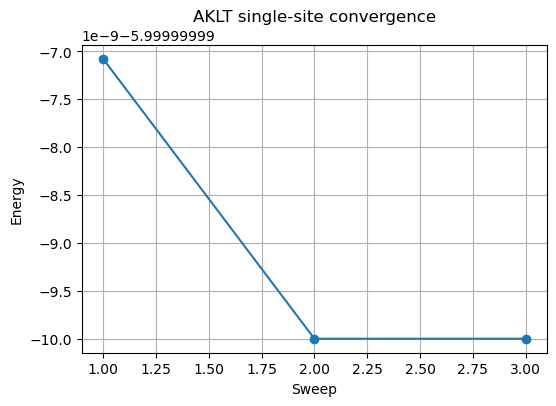

saved: figureAKLT\class_aklt_energy_convergence.png


<Figure size 600x400 with 0 Axes>

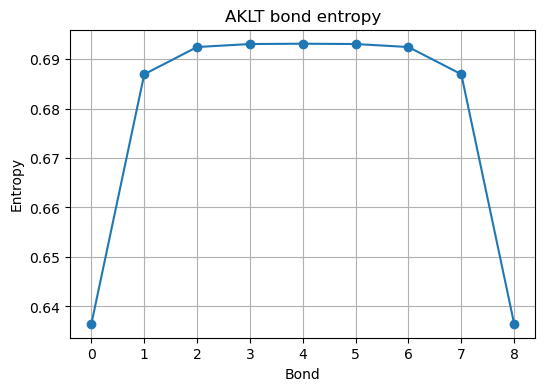

saved: figureAKLT\class_aklt_bond_entropy.png


<Figure size 600x400 with 0 Axes>

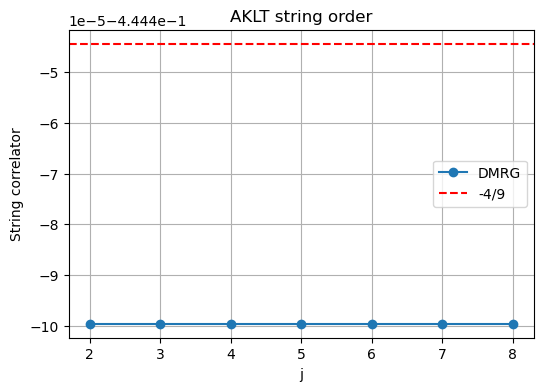

saved: figureAKLT\class_aklt_string_order.png


<Figure size 600x400 with 0 Axes>

In [ ]:
# Cell 8 — AKLT example with classes
aklt_mpo = MPO.aklt(L=10)
aklt_engine = DMRGEngine(aklt_mpo)

aklt_exact = MPS.aklt_exact(10).normalize()
print("AKLT exact MPS energy =", aklt_mpo.expectation(aklt_exact).real)

aklt_rand = MPS.random(L=10, d=3, Dmax=8, seed=7).normalize()
aklt_ss, E_aklt_ss, trunc_aklt_ss, Sent_aklt_ss = aklt_engine.single_site(
    aklt_rand, Dmax=8, nsweeps=10, energy_tol=1e-10, verbose=True
)
print("AKLT single-site energy =", aklt_mpo.expectation(aklt_ss).real)

aklt_rand2 = MPS.random(L=10, d=3, Dmax=8, seed=77).normalize()
aklt_ts, E_aklt_ts, trunc_aklt_ts = aklt_engine.two_site(
    aklt_rand2, Dmax=8, nsweeps=4, energy_tol=1e-10, verbose=True
)
print("AKLT two-site energy =", aklt_mpo.expectation(aklt_ts).real)
print("AKLT two-site bond dims =", aklt_ts.bond_dims())

Sbond_aklt = exact_bond_entropies_from_state(aklt_ss)
ops1 = spin_one_ops()
Sz1 = ops1["Sz"]
StringOp = np.diag(np.exp(1j * np.pi * np.diag(Sz1))).astype(np.complex128)

pairs, vals = [], []
for j in range(2, 9):
    pairs.append((1, j))
    vals.append(string_correlator(aklt_ss, Sz1, StringOp, Sz1, 1, j).real)

plt.figure()
plt.plot(np.arange(1, len(E_aklt_ss)+1), E_aklt_ss, marker='o')
plt.xlabel("Sweep"); plt.ylabel("Energy"); plt.title("AKLT single-site convergence")
plt.show(); savefig("class_aklt_energy_convergence.png")

plt.figure()
plt.plot(np.arange(len(Sbond_aklt)), Sbond_aklt, marker='o')
plt.xlabel("Bond"); plt.ylabel("Entropy"); plt.title("AKLT bond entropy")
plt.show(); savefig("class_aklt_bond_entropy.png")

plt.figure()
plt.plot([j for _, j in pairs], vals, marker='o', label='DMRG')
plt.axhline(-4/9, color='r', ls='--', label='-4/9')
plt.xlabel("j"); plt.ylabel("String correlator"); plt.title("AKLT string order")
plt.legend()
plt.show(); savefig("class_aklt_string_order.png")

sweep  1: E = -8.682473319644, dE = nan, trunc_sum = 4.468e-09, maxbond = 32
sweep  2: E = -8.682473319650, dE = 6.146e-12, trunc_sum = 6.728e-09, maxbond = 32
Converged early: |dE| < 1e-09
Heisenberg L=20 two-site energy = -8.682473319650136
Two-site runtime (min) = 3.0688052773475647
sweep  1: E = -8.682473319689, dE = nan, trunc_sum = 0.000e+00, Smax = 0.792414
sweep  2: E = -8.682473319690, dE = 8.527e-13, trunc_sum = 0.000e+00, Smax = 0.792414
Converged early: |dE| < 1e-10
Heisenberg L=20 refined energy = -8.682473319690148
Refinement runtime (min) = 1.9375104665756226
Final bond dims = [2, 4, 8, 16, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 16, 8, 4, 2]


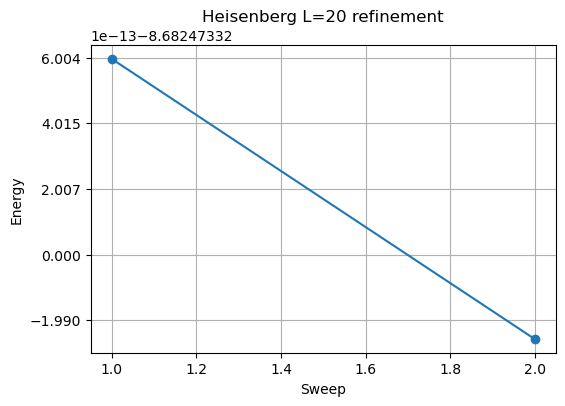

saved: figureAKLT\class_heis_refinement.png


<Figure size 600x400 with 0 Axes>

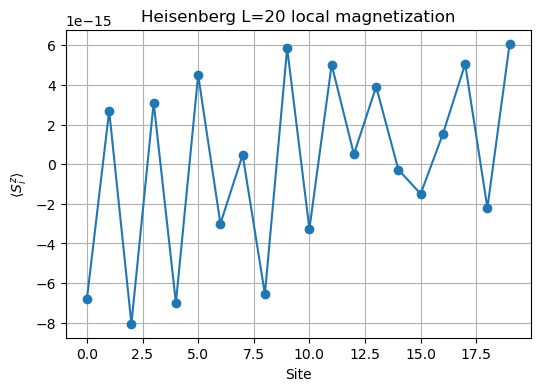

saved: figureAKLT\class_heis_local_magnetization.png


<Figure size 600x400 with 0 Axes>

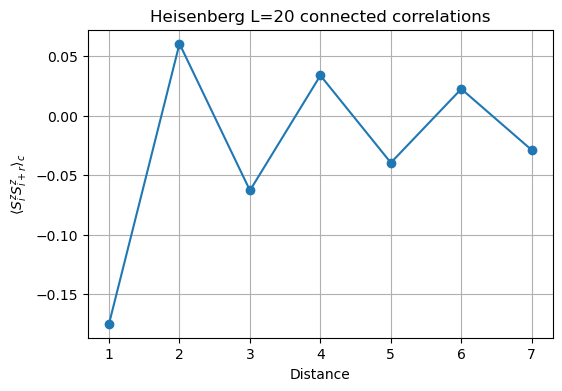

saved: figureAKLT\class_heis_connected_corr.png


<Figure size 600x400 with 0 Axes>

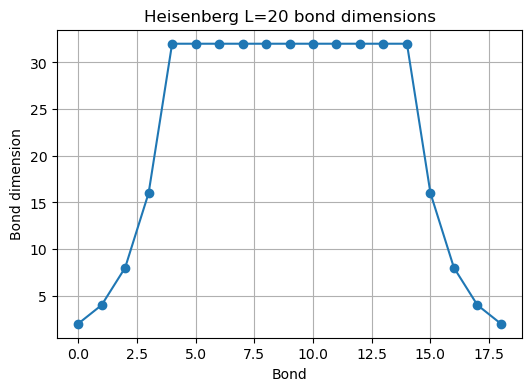

saved: figureAKLT\class_heis_bond_dims.png


<Figure size 600x400 with 0 Axes>

In [10]:
# Cell 9 — Heisenberg example with classes
heis_mpo = MPO.heisenberg(L=20)
heis_engine = DMRGEngine(heis_mpo)

heis_init = MPS.random(L=20, d=2, Dmax=32, seed=2024).normalize()

t0 = time.time()
heis_ts, E_heis_ts, trunc_heis_ts = heis_engine.two_site(
    heis_init, Dmax=32, nsweeps=4, energy_tol=1e-9, verbose=True
)
t1 = time.time()

print("Heisenberg L=20 two-site energy =", heis_mpo.expectation(heis_ts).real)
print("Two-site runtime (min) =", (t1 - t0) / 60.0)

t2 = time.time()
heis_ss, E_heis_ss, trunc_heis_ss, Sent_heis_ss = heis_engine.single_site(
    heis_ts, Dmax=32, nsweeps=6, energy_tol=1e-10, min_sweeps=1, verbose=True
)
t3 = time.time()

print("Heisenberg L=20 refined energy =", heis_mpo.expectation(heis_ss).real)
print("Refinement runtime (min) =", (t3 - t2) / 60.0)
print("Final bond dims =", heis_ss.bond_dims())

ops12 = spin_half_ops()
Sz12 = ops12["Sz"]
mz = np.array([one_site_expectation(heis_ss, Sz12, i).real for i in range(20)])
dist = np.arange(1, 8)
corr = np.array([connected_two_point(heis_ss, Sz12, 10, 10+r).real for r in dist])

plt.figure()
plt.plot(np.arange(1, len(E_heis_ss)+1), E_heis_ss, marker='o')
plt.xlabel("Sweep"); plt.ylabel("Energy"); plt.title("Heisenberg L=20 refinement")
plt.show(); savefig("class_heis_refinement.png")

plt.figure()
plt.plot(np.arange(20), mz, marker='o')
plt.xlabel("Site"); plt.ylabel(r"$\langle S_i^z \rangle$"); plt.title("Heisenberg L=20 local magnetization")
plt.show(); savefig("class_heis_local_magnetization.png")

plt.figure()
plt.plot(dist, corr, marker='o')
plt.xlabel("Distance"); plt.ylabel(r"$\langle S^z_i S^z_{i+r}\rangle_c$")
plt.title("Heisenberg L=20 connected correlations")
plt.show(); savefig("class_heis_connected_corr.png")

plt.figure()
plt.plot(np.arange(len(heis_ss.bond_dims())), heis_ss.bond_dims(), marker='o')
plt.xlabel("Bond"); plt.ylabel("Bond dimension"); plt.title("Heisenberg L=20 bond dimensions")
plt.show(); savefig("class_heis_bond_dims.png")

In [11]:
print("===== CLASS-BASED SUMMARY =====\n")

print("AKLT:")
print("  exact MPS energy   =", aklt_mpo.expectation(aklt_exact).real)
print("  single-site energy =", aklt_mpo.expectation(aklt_ss).real)
print("  two-site energy    =", aklt_mpo.expectation(aklt_ts).real)
print("  bond dims          =", aklt_ts.bond_dims())
print()

print("Heisenberg L=20:")
print("  two-site energy    =", heis_mpo.expectation(heis_ts).real)
print("  refined energy     =", heis_mpo.expectation(heis_ss).real)
print("  bond dims          =", heis_ss.bond_dims())
print()

print("Saved figures in", FIGDIR)
for f in sorted(os.listdir(FIGDIR)):
    print(" ", f)

===== CLASS-BASED SUMMARY =====

AKLT:
  exact MPS energy   = -6.000000000000001
  single-site energy = -6.0000000000000036
  two-site energy    = -6.0000000000000036
  bond dims          = [2, 2, 2, 2, 2, 2, 2, 2, 2]

Heisenberg L=20:
  two-site energy    = -8.682473319650136
  refined energy     = -8.682473319690148
  bond dims          = [2, 4, 8, 16, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 16, 8, 4, 2]

Saved figures in figureAKLT
  DMRG_convergence.png
  TwoSite_DMRG_convergence.png
  aklt_L20_convergence.png
  aklt_L20_discarded_weight.png
  aklt_L40_convergence.png
  aklt_L40_discarded_weight.png
  aklt_bond_dimensions_compare.png
  aklt_bond_entropy.png
  aklt_bond_entropy_exact_smallL.png
  aklt_dense_reference_bond_dimensions.png
  aklt_dense_reference_discarded_weight.png
  aklt_dense_reference_energy.png
  aklt_discarded_weight_compare.png
  aklt_energy.png
  aklt_energy_convergence.png
  aklt_energy_convergence_compare.png
  aklt_entanglement_entropy_L20.png
  aklt_ent